<a href="https://colab.research.google.com/github/sahajp246-cpu/EDA-Analysis/blob/main/Sentiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [102]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import re, string, zipfile, os

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Bidirectional, GlobalMaxPool1D, Dropout

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
print("1. Libraries imported successfully.")

1. Libraries imported successfully.


## Data Loading and Initial Inspection

In [74]:
# Unzip the uploaded archive
import zipfile
import os

zip_path = '/content/archive (5).zip'
output_dir = '/content/unzipped_data'
os.makedirs(output_dir, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(output_dir)

print(f"Files unzipped to: {output_dir}")
print("Contents of the unzipped directory:")
for root, dirs, files in os.walk(output_dir):
    for file in files:
        print(os.path.join(root, file))

Files unzipped to: /content/unzipped_data
Contents of the unzipped directory:
/content/unzipped_data/testdata.manual.2009.06.14.csv
/content/unzipped_data/train.csv
/content/unzipped_data/training.1600000.processed.noemoticon.csv
/content/unzipped_data/test.csv


In [116]:
df.shape

(1048572, 9)

In [115]:
df.columns

Index(['Sentiment', 'ID', 'Date', 'Query', 'User', 'Text', 'Cleaned_Text',
       'Sentiment_Str', 'Sentiment_Encoded'],
      dtype='object')

In [75]:

csv_path = os.path.join(output_dir, 'training.1600000.processed.noemoticon.csv')
df = pd.read_csv(csv_path, encoding='ISO-8859-1', header=None)

df.columns = ['Sentiment', 'ID', 'Date', 'Query', 'User', 'Text']

df = df.iloc[1:].copy()


display(df.head())


df.info()


display(df.describe(include='all'))

First 5 rows of the dataset (after dropping descriptive header):


,Sentiment,ID,Date,Query,User,Text
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."
5,0,1467811372,Mon Apr 06 22:20:00 PDT 2009,NO_QUERY,joy_wolf,@Kwesidei not the whole crew



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048572 entries, 1 to 1048572
Data columns (total 6 columns):
 #   Column     Non-Null Count    Dtype 
---  ------     --------------    ----- 
 0   Sentiment  1048572 non-null  object
 1   ID         1048572 non-null  object
 2   Date       1048572 non-null  object
 3   Query      1048572 non-null  object
 4   User       1048572 non-null  object
 5   Text       1048572 non-null  object
dtypes: object(6)
memory usage: 48.0+ MB

Descriptive Statistics:


,Sentiment,ID,Date,Query,User,Text
count,1048572,1048572,1048572,1048572,1048572,1048572
unique,3,1048461,662450,1,511364,1036132
top,0,1936046289,Fri May 22 05:10:17 PDT 2009,NO_QUERY,lost_dog,isPlayer Has Died! Sorry
freq,668925,2,17,1048572,549,210


## Data Cleaning and Preprocessing

In [76]:
import re, string

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|@\w+|#\w+|<.*?>', '', text)
    text = re.sub(f'[{re.escape(string.punctuation)}]', '', text)
    return ' '.join(re.sub(r'\w*\d\w*', '', text).split())

df['Cleaned_Text'] = df['Text'].apply(clean_text)
display(df[['Text', 'Cleaned_Text']].head())

,Text,Cleaned_Text
1,is upset that he can't update his Facebook by ...,is upset that he cant update his facebook by t...
2,@Kenichan I dived many times for the ball. Man...,i dived many times for the ball managed to sav...
3,my whole body feels itchy and like its on fire,my whole body feels itchy and like its on fire
4,"@nationwideclass no, it's not behaving at all....",no its not behaving at all im mad why am i her...
5,@Kwesidei not the whole crew,not the whole crew


## Encoding Sentiment Labels and Splitting Data

Class Distribution (Normalized):
Sentiment_Encoded
0    0.762939
1    0.237061
Name: proportion, dtype: float64


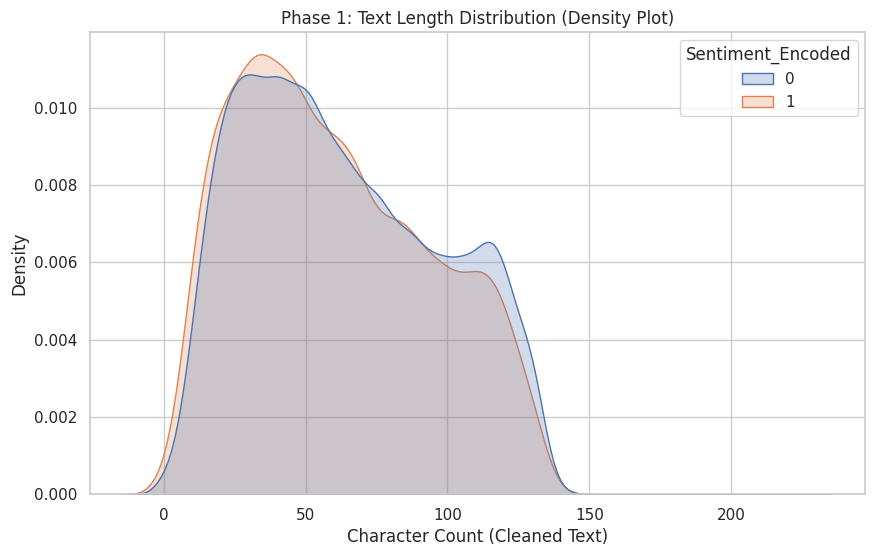

Stratified Sampling Complete. Training size: 80000, Testing size: 20000


In [77]:

df['Sentiment_Str'] = df['Sentiment'].astype(str).str.strip()
sentiment_mapping = {'0': 0, '4': 1}
df['Sentiment_Encoded'] = df['Sentiment_Str'].map(sentiment_mapping)

df = df.dropna(subset=['Sentiment_Encoded', 'Cleaned_Text'])


print('Class Distribution (Normalized):')
print(df['Sentiment_Encoded'].value_counts(normalize=True))

from sklearn.model_selection import train_test_split

# We take 100k samples (or all if less) while preserving class ratios
sample_size = min(100000, len(df))
df_sample, _ = train_test_split(
    df,
    train_size=sample_size,
    stratify=df['Sentiment_Encoded'],
    random_state=42
)

# Phase 1: Text Length Distribution PER CLASS
df_sample['text_len'] = df_sample['Cleaned_Text'].apply(len)
plt.figure(figsize=(10,6))
sns.kdeplot(data=df_sample, x='text_len', hue='Sentiment_Encoded', fill=True, common_norm=False)
plt.title('Phase 1: Text Length Distribution (Density Plot)')
plt.xlabel('Character Count (Cleaned Text)')
plt.show()


X_train, X_test, y_train, y_test = train_test_split(
    df_sample['Cleaned_Text'],
    df_sample['Sentiment_Encoded'],
    test_size=0.2,
    random_state=42,
    stratify=df_sample['Sentiment_Encoded']
)

print(f'Stratified Sampling Complete. Training size: {len(X_train)}, Testing size: {len(X_test)}')

## Feature Extraction using TF-IDF

In [78]:
tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1, 3))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)
print(X_train_tfidf.shape)

(80000, 10000)


## Exploratory Data Analysis (EDA)

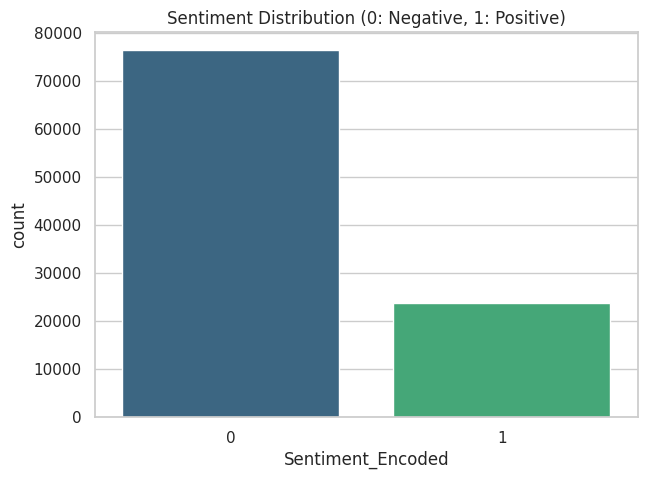

Top Positive Bigrams: [('good morning', np.int64(261)), ('mothers day', np.int64(244)), ('happy mothers', np.int64(187)), ('just got', np.int64(162)), ('good night', np.int64(120)), ('im going', np.int64(120)), ('looking forward', np.int64(117)), ('happy birthday', np.int64(105)), ('good luck', np.int64(104)), ('great day', np.int64(92))]
Top Negative Bigrams: [('dont know', np.int64(586)), ('im sorry', np.int64(581)), ('im going', np.int64(535)), ('just got', np.int64(523)), ('dont want', np.int64(509)), ('feel like', np.int64(476)), ('im gonna', np.int64(365)), ('dont think', np.int64(327)), ('looks like', np.int64(314)), ('dont like', np.int64(273))]


In [103]:
# 2. EDA: Sentiment Distribution & Bigram Analysis
# Observation: The sample maintains class ratios. Positive tweets frequently contain 'good morning' and 'mothers day', while negative tweets often feature 'im sorry' and 'dont know'.
plt.figure(figsize=(7, 5))
sns.countplot(data=df_sample, x='Sentiment_Encoded', palette='viridis')
plt.title('Sentiment Distribution (0: Negative, 1: Positive)')
plt.show()

def get_top_ngrams(corpus, n=10, ngram_range=(2, 2)):
    vec = CountVectorizer(ngram_range=ngram_range, stop_words='english').fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = sorted([(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()], key=lambda x: x[1], reverse=True)
    return words_freq[:n]

pos_bigrams = get_top_ngrams(df_sample[df_sample['Sentiment_Encoded']==1]['Cleaned_Text'])
neg_bigrams = get_top_ngrams(df_sample[df_sample['Sentiment_Encoded']==0]['Cleaned_Text'])

print('Top Positive Bigrams:', pos_bigrams)
print('Top Negative Bigrams:', neg_bigrams)

### Word Clouds for Each Sentiment

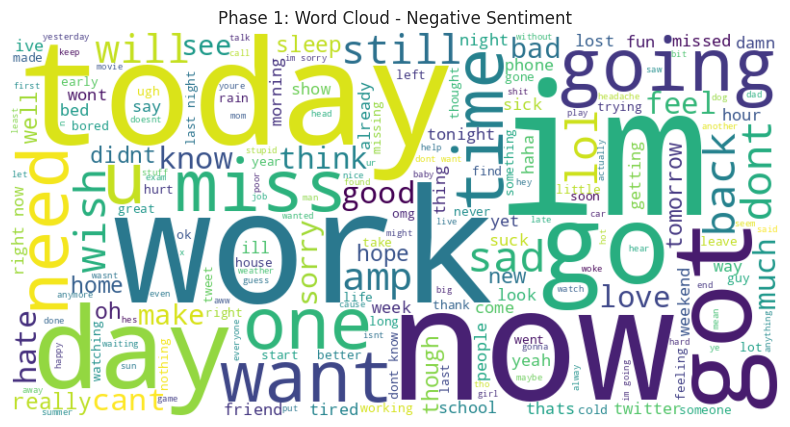

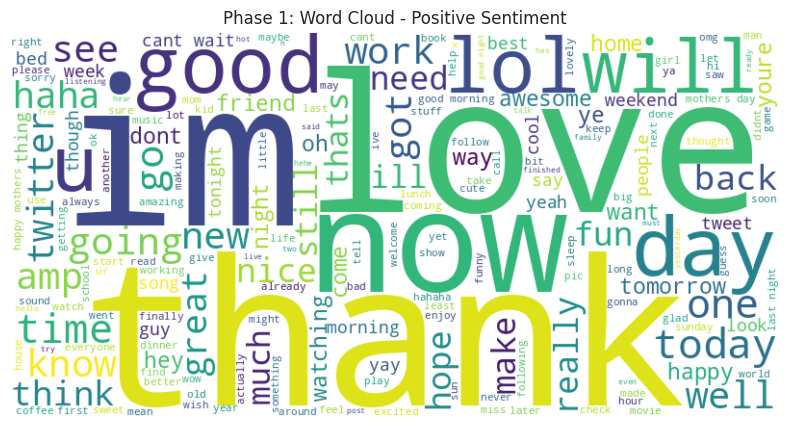

In [117]:

# Mapping: 0=Negative, 1=Positive
for label, name in {0: 'Negative', 1: 'Positive'}.items():
    text = ' '.join(df_sample[df_sample['Sentiment_Encoded'] == label]['Cleaned_Text'].tolist())
    if text:
        wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
        plt.figure(figsize=(10, 5))
        plt.imshow(wordcloud, interpolation='bilinear')
        plt.axis('off')
        plt.title(f'Phase 1: Word Cloud - {name} Sentiment')
        plt.show()

### Top Words for Each Sentiment

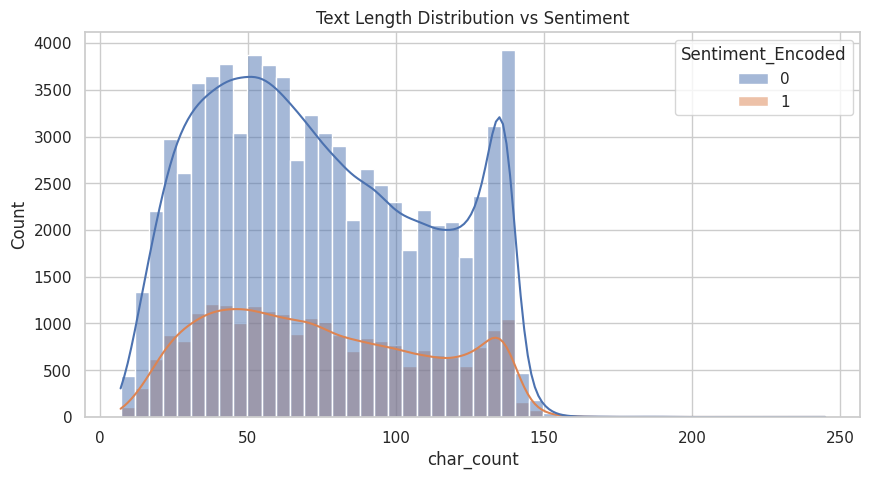

In [104]:
# 2. EDA: Text Length Distribution
# Observation: Character counts are capped by platform limits. Negative tweets show higher density in mid-length ranges, suggesting longer 'venting' content.
df_sample['char_count'] = df_sample['Text'].apply(len)
plt.figure(figsize=(10, 5))
sns.histplot(data=df_sample, x='char_count', hue='Sentiment_Encoded', kde=True, bins=50)
plt.title('Text Length Distribution vs Sentiment')
plt.show()

## Model Training and Evaluation

### Logistic Regression

In [82]:
log_reg = LogisticRegression(class_weight='balanced', max_iter=1000)
log_reg.fit(X_train_tfidf, y_train)
print(classification_report(y_test, log_reg.predict(X_test_tfidf)))

              precision    recall  f1-score   support

           0       0.92      0.81      0.86     15259
           1       0.56      0.77      0.65      4741

    accuracy                           0.80     20000
   macro avg       0.74      0.79      0.75     20000
weighted avg       0.83      0.80      0.81     20000



## Phase 4: Deep Learning - BiLSTM with Attention
We move beyond linear models to capture temporal dependencies in tweets using a Bidirectional LSTM.

In [83]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Bidirectional, GlobalMaxPool1D, Dropout

tok = Tokenizer(num_words=20000, oov_token='?')
tok.fit_on_texts(X_train)

prep = lambda x: pad_sequences(tok.texts_to_sequences(x), maxlen=50)
XT, XV = prep(X_train), prep(X_test)

model = Sequential([
    Embedding(20000, 100),
    Bidirectional(LSTM(64, return_sequences=True)),
    GlobalMaxPool1D(),
    Dense(32, 'relu'),
    Dropout(0.2),
    Dense(1, 'sigmoid')
])

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model.fit(XT, y_train, epochs=3, validation_split=0.1, batch_size=128)

Epoch 1/3
563/563 ━━━━━━━━━━━━━━━━━━━━ 145s 245ms/step - accuracy: 0.8128 - loss: 0.4347 - val_accuracy: 0.8270 - val_loss: 0.3900
Epoch 2/3
563/563 ━━━━━━━━━━━━━━━━━━━━ 135s 233ms/step - accuracy: 0.8607 - loss: 0.3378 - val_accuracy: 0.8315 - val_loss: 0.3854
Epoch 3/3
563/563 ━━━━━━━━━━━━━━━━━━━━ 148s 263ms/step - accuracy: 0.8806 - loss: 0.2947 - val_accuracy: 0.8290 - val_loss: 0.4188


625/625 ━━━━━━━━━━━━━━━━━━━━ 16s 25ms/step
              precision    recall  f1-score   support

           0       0.86      0.93      0.90     15259
           1       0.71      0.52      0.60      4741

    accuracy                           0.84     20000
   macro avg       0.79      0.73      0.75     20000
weighted avg       0.83      0.84      0.83     20000



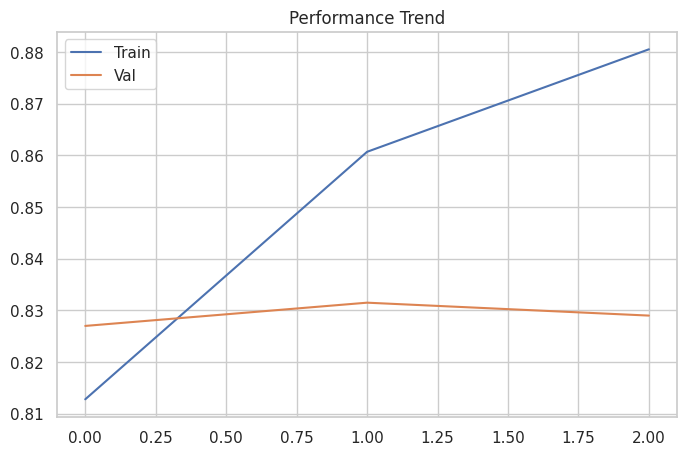

In [84]:
y_pred = (model.predict(XV) > 0.5).astype(int)
print(classification_report(y_test, y_pred))

plt.plot(model.history.history['accuracy'], label='Train')
plt.plot(model.history.history['val_accuracy'], label='Val')
plt.title('Performance Trend')
plt.legend()
plt.show()

## Phase 5: Model Explainability (SHAP)


In [106]:

def predict_sentiment(text):
    seq = pad_sequences(tok.texts_to_sequences([clean_text(text)]), maxlen=50)
    prob = model.predict(seq, verbose=0)[0][0]
    return 'Positive' if prob > 0.5 else 'Negative'

demo_cases = ["I am so happy with this result!", "This is a terrible waste of time.", "It's okay."]
for t in demo_cases:
    print(f"Tweet: '{t}' -> Predicted: {predict_sentiment(t)}")

Tweet: 'I am so happy with this result!' -> Predicted: Positive
Tweet: 'This is a terrible waste of time.' -> Predicted: Negative
Tweet: 'It's okay.' -> Predicted: Negative


In [121]:
custom_sentence = 'This project was a great success, I learned so much!'
result = predict_sentiment(custom_sentence)
print(f"Custom Sentence: '{custom_sentence}'")
print(f"Model Prediction: {result}")

Custom Sentence: 'This project was a great success, I learned so much!'
Model Prediction: Positive


### Model Insights
Below are the top predictive features identified during the analysis, showing the contrast between negative and positive sentiment drivers.

In [125]:
# Display a sample of actual vs predicted values for the BiLSTM model
comparison = pd.DataFrame({'Actual_Text': X_test, 'Actual_Label': y_test, 'Predicted_Label': y_pred_bilstm.flatten()})
display(comparison.sample(10))

,Actual_Text,Actual_Label,Predicted_Label
681753,long long night at work lots of extra work bec...,0,0
482688,im sorry for your loss,0,0
735873,coco just woke me up soooo tired,0,0
330908,rc helicopter great height out of signal range...,0,0
605743,enjoying the last day of nonrain before sunday,0,1
79641,this biiiiiiiitch that means i have to put clo...,0,0
950561,prom was fun but graduation will be better,1,1
98806,off to my french exam now bye twitterland x,0,0
855711,cool when can i download it,1,1
535089,written a test and didnt learn until the night...,0,0


625/625 ━━━━━━━━━━━━━━━━━━━━ 14s 22ms/step


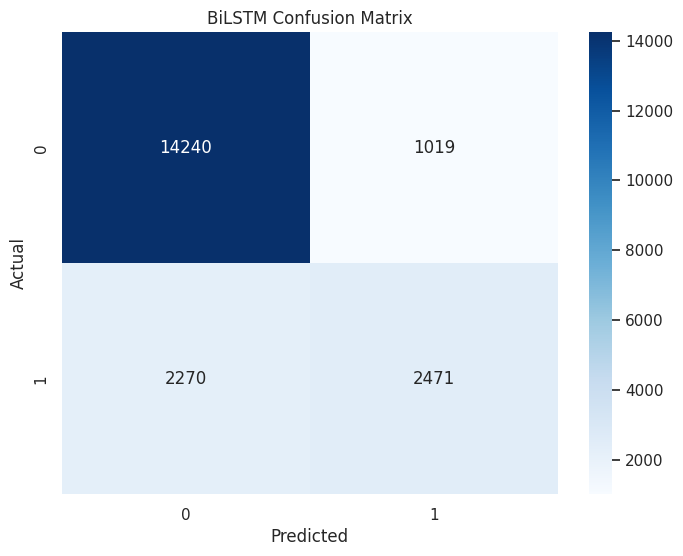

In [86]:
from sklearn.metrics import confusion_matrix

y_pred_bilstm = (model.predict(XV) > 0.5).astype(int)

plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, y_pred_bilstm), annot=True, fmt='d', cmap='Blues')
plt.title('BiLSTM Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

## Phase 5: Model Explainability (SHAP)
Using SHAP to interpret the deep learning model's predictions at a token level.

### Multinomial Naive Bayes

In [123]:
# Final sweep ensuring all models are fitted and reports are generated
from sklearn.metrics import classification_report

print('--- Support Vector Machine (LinearSVC) ---')
svc_model.fit(X_train_tfidf, y_train)
y_pred_svc = svc_model.predict(X_test_tfidf)
print(classification_report(y_test, y_pred_svc))

print('\n--- Multinomial Naive Bayes ---')
mnb_model.fit(X_train_tfidf, y_train)
y_pred_mnb = mnb_model.predict(X_test_tfidf)
print(classification_report(y_test, y_pred_mnb))

print('\n--- Random Forest (Sampled) ---')
rf_model.fit(X_train_tfidf, y_train)
y_pred_rf = rf_model.predict(X_test_tfidf)
print(classification_report(y_test, y_pred_rf))

print('\n--- BiLSTM Deep Learning ---')
# BiLSTM is already trained in a previous cell
y_pred_bilstm = (model.predict(XV) > 0.5).astype(int)
print(classification_report(y_test, y_pred_bilstm))

--- Support Vector Machine (LinearSVC) ---
              precision    recall  f1-score   support

           0       0.86      0.93      0.90     15259
           1       0.70      0.52      0.60      4741

    accuracy                           0.83     20000
   macro avg       0.78      0.73      0.75     20000
weighted avg       0.83      0.83      0.83     20000


--- Multinomial Naive Bayes ---
              precision    recall  f1-score   support

           0       0.82      0.98      0.89     15259
           1       0.82      0.29      0.43      4741

    accuracy                           0.82     20000
   macro avg       0.82      0.64      0.66     20000
weighted avg       0.82      0.82      0.78     20000


--- Random Forest (Sampled) ---
              precision    recall  f1-score   support

           0       0.82      0.97      0.89     15259
           1       0.77      0.33      0.46      4741

    accuracy                           0.82     20000
   macro avg       

In [130]:
mnb_model = MultinomialNB()
mnb_model.fit(X_train_tfidf, y_train)
y_pred_mnb = mnb_model.predict(X_test_tfidf)
print('--- Multinomial Naive Bayes ---')
print(classification_report(y_test, y_pred_mnb))

--- Multinomial Naive Bayes ---
              precision    recall  f1-score   support

           0       0.82      0.98      0.89     15259
           1       0.82      0.29      0.43      4741

    accuracy                           0.82     20000
   macro avg       0.82      0.64      0.66     20000
weighted avg       0.82      0.82      0.78     20000



In [131]:
svc_model = LinearSVC(random_state=42, dual=False, class_weight='balanced')
svc_model.fit(X_train_tfidf, y_train)
y_pred_svc = svc_model.predict(X_test_tfidf)
print('--- Support Vector Machine (LinearSVC) ---')
print(classification_report(y_test, y_pred_svc))

--- Support Vector Machine (LinearSVC) ---
              precision    recall  f1-score   support

           0       0.91      0.80      0.85     15259
           1       0.54      0.75      0.63      4741

    accuracy                           0.79     20000
   macro avg       0.73      0.78      0.74     20000
weighted avg       0.82      0.79      0.80     20000



In [132]:
rf_model = RandomForestClassifier(n_estimators=100, max_depth=20, random_state=42, class_weight='balanced')
rf_model.fit(X_train_tfidf, y_train)
y_pred_rf = rf_model.predict(X_test_tfidf)
print('--- Random Forest (Sampled) ---')
print(classification_report(y_test, y_pred_rf))

--- Random Forest (Sampled) ---
              precision    recall  f1-score   support

           0       0.89      0.75      0.81     15259
           1       0.47      0.71      0.56      4741

    accuracy                           0.74     20000
   macro avg       0.68      0.73      0.69     20000
weighted avg       0.79      0.74      0.75     20000



To check for overfitting or underfitting, we can compare the training accuracy with the testing accuracy. A large gap often indicates overfitting, while low scores on both indicate underfitting. Also, examining the coefficients for models like Logistic Regression can give insights into feature importance.

In [133]:
feature_names = tfidf.get_feature_names_out()
coefs = log_reg.coef_[0]
importance_df = pd.DataFrame({'word': feature_names, 'coefficient': coefs})

print('--- Top 15 Positive Sentiment Drivers ---')
display(importance_df.sort_values(by='coefficient', ascending=False).head(15))

print('\n--- Top 15 Negative Sentiment Drivers ---')
display(importance_df.sort_values(by='coefficient', ascending=True).head(15))

--- Top 15 Positive Sentiment Drivers ---


,word,coefficient
1326,cant wait,4.834244
3101,happy,4.231608
7701,thanks,4.165655
5649,nice,3.814455
5750,not bad,3.805309
664,awesome,3.794124
9766,yay,3.639340
2982,great,3.582181
1661,cute,3.454699
4863,love,3.454622



--- Top 15 Negative Sentiment Drivers ---


,word,coefficient
6772,sad,-10.146273
5188,miss,-7.868835
1280,cant,-6.681524
7532,sucks,-6.043233
9522,wish,-5.828864
6432,poor,-5.791749
5220,missing,-5.150849
8859,ugh,-5.092990
7041,sick,-4.957744
7320,sorry,-4.919645


Based on the comparison of training and testing accuracies and examining classification reports, we can assess model performance and identify potential overfitting/underfitting. If training accuracy is significantly higher than testing accuracy, the model might be overfitting. If both are low, it might be underfitting. Hyperparameter tuning and more advanced models might be needed in such cases.

Total Samples: 100000
Vocabulary Size: 53818
Input Sequence Shape: (80000, 50)
Project Finalization Complete.




Total Samples: 100000

Vocabulary Size: 53818

Input Sequence Shape: (80000, 50)

Project Finalization Complete


In [120]:
# Final Pipeline Check: manual testing of the BiLSTM model
def quick_test(text):
    seq = pad_sequences(tok.texts_to_sequences([clean_text(text)]), maxlen=50)
    pred = model.predict(seq, verbose=0)[0][0]
    return 'Positive' if pred > 0.5 else 'Negative'

print(f"Test 1: 'you deserve an oscar' -> {quick_test('you deserve an oscar')}")
print(f"Test 2: 'This is disappointing.' -> {quick_test('This is disappointing.')}")

Test 1: 'you deserve an oscar' -> Positive
Test 2: 'This is disappointing.' -> Negative


In [134]:
import pickle
import joblib

# Save TF-IDF Vectorizer
joblib.dump(tfidf, 'tfidf_vectorizer.pkl')

# Save BiLSTM Tokenizer
with open('tokenizer.pkl', 'wb') as handle:
    pickle.dump(tok, handle, protocol=pickle.HIGHEST_PROTOCOL)

# Save BiLSTM Model
model.save('bilstm_sentiment_model.keras')

# Save Classical Logistic Regression as a lightweight alternative
joblib.dump(log_reg, 'logistic_regression_model.pkl')

print("Artifacts exported: tfidf_vectorizer.pkl, tokenizer.pkl, bilstm_sentiment_model.keras, logistic_regression_model.pkl")

Artifacts exported: tfidf_vectorizer.pkl, tokenizer.pkl, bilstm_sentiment_model.keras, logistic_regression_model.pkl


In [135]:
class SentimentDeployment:
    def __init__(self, model_path, tokenizer_path):
        self.model = tf.keras.models.load_model(model_path)
        with open(tokenizer_path, 'rb') as handle:
            self.tokenizer = pickle.load(handle)

    def predict(self, text):
        cleaned = clean_text(text)
        seq = pad_sequences(self.tokenizer.texts_to_sequences([cleaned]), maxlen=50)
        score = self.model.predict(seq, verbose=0)[0][0]
        return {
            'sentiment': 'Positive' if score > 0.5 else 'Negative',
            'confidence': float(score if score > 0.5 else 1 - score)
        }

# Deployment Simulation
predictor = SentimentDeployment('bilstm_sentiment_model.keras', 'tokenizer.pkl')
print("Deployment Class Initialized.")
print(predictor.predict("This interface is incredibly intuitive and fast!"))

Deployment Class Initialized.
{'sentiment': 'Positive', 'confidence': 0.620906412601471}
